c:\Users\shrin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


📏 Silhouette Score (UMAP): 0.3985


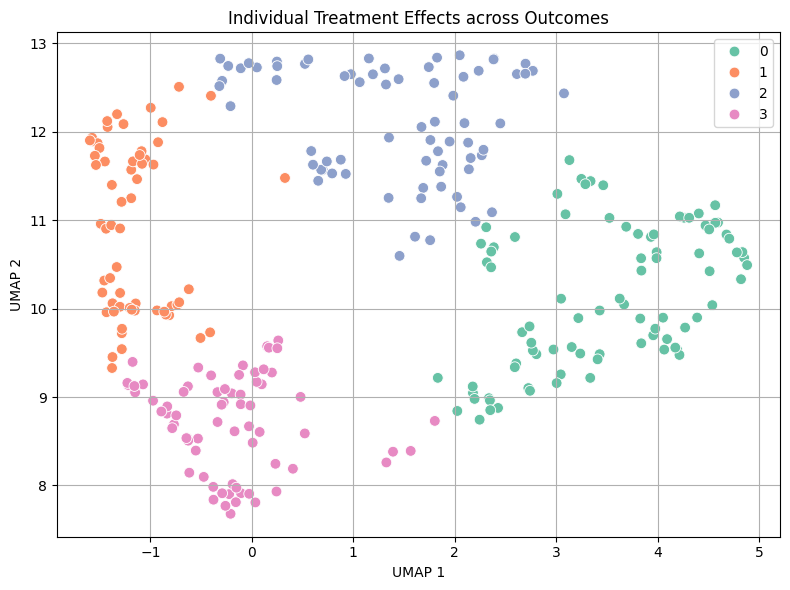

In [1]:
from modules.cluster import generate_cate_matrix, umap_cluster_cates, visualize_clusters, visualize_clusters_3d_plotly, plot_cate_tradeoff
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from modules.preprocess import load_and_clean_data, prepare_variables



# Step 1: prepare baseline
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, outcome_col='mrs_binary')  # any outcome will do, X is same

# Step 2: define CATE sources
cate_file_dict = {
    "mrs_binary": "cate_results/cate_results_mrs_binary.csv",
    "infarct_dch": "cate_results/cate_results_infarct_dch.csv",
    "vs_clin": "cate_results/cate_results_vs_clin.csv",
    "infection_dch": "cate_results/cate_results_infection_dch.csv",
    "gos_binary": "cate_results/cate_results_gos_binary.csv",
    "shunt_180": "cate_results/cate_results_shunt_180.csv",
}

# Step 3: build matrix
cate_matrix = generate_cate_matrix(X, cate_file_dict)


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

import matplotlib.pyplot as plt
import seaborn as sns



# Step 4: UMAP-based cluster
X_umap, clusters, reducer, kmeans = umap_cluster_cates(cate_matrix, n_clusters=4)
# Step 5: Visualize
visualize_clusters(X_umap, clusters, method="UMAP")


In [2]:
visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=None , method="UMAP")

c:\Users\shrin\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [3]:
fig = visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=kmeans, method="UMAP")

# 🧹 Strip unsafe template
fig.layout.template = "none"

# ✅ Save clean figure
import plotly.io as pio
pio.write_json(fig, "clusters/umap_plot.json", pretty=True)


In [4]:
from joblib import dump



# Save UMAP + KMeans
dump(X_umap, "clusters/umap_embedding.joblib")
dump(clusters, "clusters/umap_clusters.joblib")
dump(reducer, "clusters/umap_model.joblib")         
dump(kmeans, "clusters/kmeans_model.joblib")       


['clusters/kmeans_model.joblib']

In [5]:
import pandas as pd
df_clustered = pd.DataFrame(X, columns=feature_names)
df_clustered['cluster'] = clusters

# Compare means across clusters
cluster_summary = df_clustered.groupby('cluster').mean()
print(cluster_summary)


               age        hh    ct_ivh    ct_ich       sex  aneurysm_trt  \
cluster                                                                    
0        53.139535  2.662791  0.511628  0.255814  0.325581      0.569767   
1        54.590164  3.295082  0.721311  0.442623  0.213115      0.426230   
2        52.211268  2.422535  0.422535  0.239437  0.394366      0.577465   
3        62.579710  3.594203  0.826087  0.579710  0.304348      0.449275   

         aneurysm_circulation   mrs_adm  aneurysm_size  aneurysm_no  ...  \
cluster                                                              ...   
0                    0.790698  0.941860       7.775466     1.372093  ...   
1                    0.918033  0.950820       7.141574     1.311475  ...   
2                    0.901408  0.957746       6.162344     1.323944  ...   
3                    0.797101  0.898551       7.123384     1.579710  ...   

         ct_modfisher        bmi  rr_map_mean  rr_syst_mean  rr_dia_mean  \
cluster   

In [6]:
cate_df = pd.DataFrame(cate_matrix, columns=list(cate_file_dict.keys()))
cate_df['cluster'] = clusters

# Mean CATEs per cluster
print(cate_df.groupby('cluster').mean())


         mrs_binary  infarct_dch   vs_clin  infection_dch  gos_binary  \
cluster                                                                 
0          0.052661     0.059105 -0.078310       0.074415   -0.056344   
1          0.003295     0.028911 -0.092623       0.019618   -0.056666   
2          0.049707     0.072171 -0.053268       0.066642   -0.059622   
3         -0.013921     0.015946 -0.121347      -0.005348   -0.048066   

         shunt_180  
cluster             
0        -0.024025  
1         0.125442  
2         0.087522  
3         0.036445  


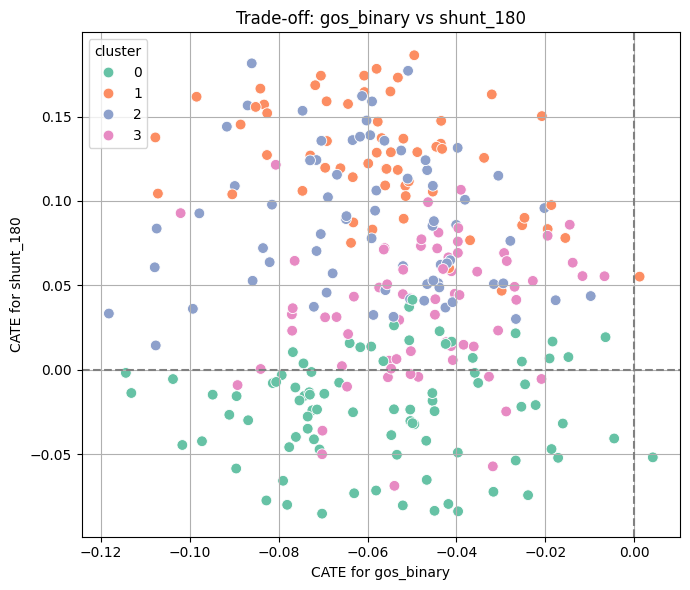

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cate_df = pd.DataFrame(cate_matrix, columns=cate_file_dict.keys())
cate_df['cluster'] = clusters

plot_cate_tradeoff(cate_df, "gos_binary", "shunt_180", clusters=cate_df['cluster'])
